In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.shape

(100, 4)

Preprocess

In [ ]:
df=df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


EDA

In [ ]:
import matplotlib.pyplot as plt

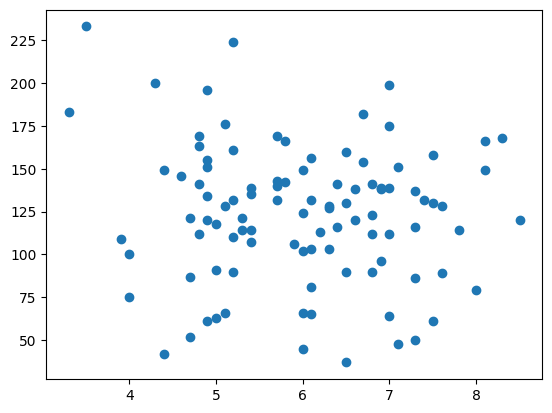

In [ ]:
plt.scatter(df['cgpa'],df['iq'])

plt-> plotting Lib                        
scatter() -> creates
a scatter plot                                           
df['cgpa'] -> values on the X-axis                        
df['iq']-> values on y axis


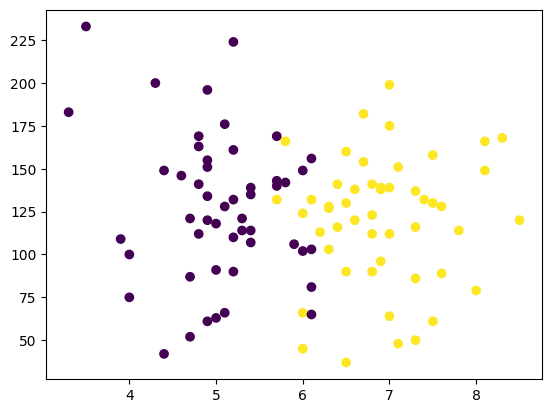

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

c=df['placement']->color of each dot  
Each dot=one student  
placement = 1 → placed
placement = 0 → not placed

**Extract Input(col 0 and 1) and output(col 2) cols**

In [ ]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

:-> all column      
0:2-> means column 0 and 1           
-1: last column

In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
Y.shape


(100,)

In [ ]:
X.shape

(100, 2)

Separate data for both training and test

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [ ]:
X_train

,cgpa,iq
40,4.9,134.0
8,6.1,156.0
70,6.3,127.0
89,4.9,151.0
13,6.4,116.0
...,...,...
53,8.3,168.0
7,5.0,63.0
71,6.1,132.0
11,6.9,138.0


In [ ]:
Y_train


,placement
40,0
8,0
70,1
89,0
13,1
...,...
53,1
7,0
71,1
11,1


Data scaling: changing the range of your numerical data so all features are on a similar scale

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
x_train=scaler.fit_transform(X_train)

In [ ]:
X_train

,cgpa,iq
40,4.9,134.0
8,6.1,156.0
70,6.3,127.0
89,4.9,151.0
13,6.4,116.0
...,...,...
53,8.3,168.0
7,5.0,63.0
71,6.1,132.0
11,6.9,138.0


In [ ]:
X_test=scaler.transform(X_test)

In [ ]:
X_test

array([[ 0.09192346, -0.44234589],
       [-2.45364926,  1.56451635],
       [-0.27172979,  0.28514168],
       [ 0.91014326,  0.46074212],
       [-0.99903628,  1.89063147],
       [-1.1808629 ,  0.00919812],
       [ 1.36470982,  0.9373719 ],
       [-1.08994959,  1.21331546],
       [ 1.91018969,  0.7115999 ],
       [ 1.00105657,  0.76177146]])

Model Train

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf=LogisticRegression()

In [ ]:
clf.fit(X_train,Y_train)


LogisticRegression()

In [ ]:
y_pred=clf.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
Y_test


,placement
14,0
17,0
87,1
32,1
80,0
24,0
91,1
75,0
37,1
21,1


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(Y_test,y_pred)

0.5

In [ ]:
from mlxtend.plotting import plot_decision_regions


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

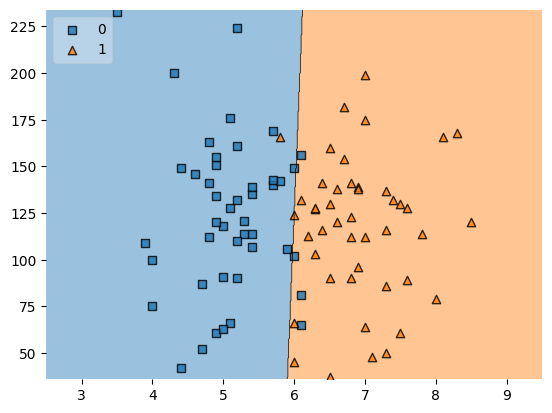

In [ ]:
plot_decision_regions(X_train.values, Y_train.values, clf=clf, legend=2)

Saving trained model to a file



In [ ]:
import pickle

In [ ]:
pickle.dump(clf,open('/model.pkl','wb'))